# Lecture 01 — Mathematical Foundations

**Learning objectives**

- Manipulate vectors and matrices: inner products, norms, matrix products, and their geometric meaning.
- Compute and interpret the eigendecomposition of a symmetric matrix and the singular value decomposition (SVD) of any matrix; use the SVD for low-rank approximation.
- Compute gradients and Jacobians of multivariate functions, apply the chain rule, and verify analytic gradients numerically (gradient checking).
- Work with random variables, expectation and variance, the (multivariate) Gaussian, and Bayes' rule.
- Derive the maximum-likelihood estimator (MLE) of a Gaussian, verify its properties by simulation, and contrast it with maximum a posteriori (MAP) estimation.
- Recognize convex problems, run gradient descent, understand the effect of the learning rate and conditioning, and use stochastic gradient descent and momentum.

**Prerequisites**

- `00_course_introduction_and_python_toolkit.ipynb` (NumPy, plotting, the learning problem).
- First-year calculus and linear algebra.

**Contents**

1. Linear algebra
2. Multivariate calculus
3. Probability and statistics
4. Estimation: MLE and MAP
5. Optimization
6. Pitfalls & practical tips
7. Exercises
8. Summary and further reading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 1. Linear algebra

### 1.1 Vectors, inner products and norms

A vector $x\in\mathbb{R}^d$ is a column of $d$ numbers. The **inner product** $\langle x, y\rangle = x^\top y = \sum_i x_i y_i$
induces the geometry of the space:
$$x^\top y = \|x\|_2\,\|y\|_2 \cos\theta .$$
A **norm** $\|\cdot\|$ satisfies positivity ($\|x\|=0 \iff x=0$), homogeneity ($\|\alpha x\| = |\alpha|\|x\|$)
and the triangle inequality. The $\ell_p$ norms
$$\|x\|_p = \Big(\sum_{i=1}^d |x_i|^p\Big)^{1/p},\qquad \|x\|_\infty = \max_i |x_i|,$$
are used constantly in ML: $\ell_2$ for Euclidean distance and Ridge regularization, $\ell_1$ for Lasso (sparsity),
$\ell_\infty$ in robustness. The **Cauchy–Schwarz inequality** $|x^\top y| \le \|x\|_2\|y\|_2$ follows from
$\cos\theta\in[-1,1]$.

In [2]:
x = np.array([3.0, -4.0, 0.0]); y = np.array([1.0, 2.0, 2.0])
print("x.y =", x @ y)
for p in [1, 2, np.inf]:
    print(f"||x||_{p} = {np.linalg.norm(x, ord=p):.4f}   (manual: {np.sum(np.abs(x)**p)**(1/p) if p != np.inf else np.max(np.abs(x)):.4f})")
cos = x @ y / (np.linalg.norm(x) * np.linalg.norm(y))
print(f"cos(theta) = {cos:.4f}, theta = {np.degrees(np.arccos(cos)):.2f} deg; Cauchy-Schwarz holds: {abs(x@y) <= np.linalg.norm(x)*np.linalg.norm(y)}")

x.y = -5.0
||x||_1 = 7.0000   (manual: 7.0000)
||x||_2 = 5.0000   (manual: 5.0000)
||x||_inf = 4.0000   (manual: 4.0000)
cos(theta) = -0.3333, theta = 109.47 deg; Cauchy-Schwarz holds: True


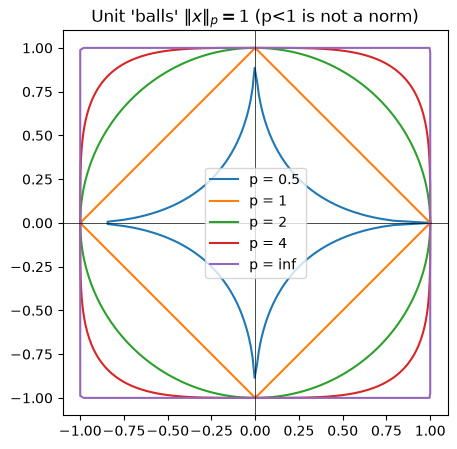

In [3]:
# Unit balls {x : ||x||_p = 1} in 2-D for several p
theta = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(5, 5))
for p in [0.5, 1, 2, 4, np.inf]:
    u = np.stack([np.cos(theta), np.sin(theta)])
    r = np.linalg.norm(u, ord=p, axis=0)          # rescale every direction to have p-norm 1
    ax.plot(u[0] / r, u[1] / r, label=f"p = {p}")
ax.set_aspect("equal"); ax.legend(); ax.set_title(r"Unit 'balls' $\|x\|_p = 1$ (p<1 is not a norm)")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5); plt.show()

The $\ell_1$ ball has corners on the axes; this geometry is why $\ell_1$ regularization produces sparse solutions
(Lecture 02).

### 1.2 Matrix products

For $A\in\mathbb{R}^{m\times n}$, $B\in\mathbb{R}^{n\times p}$, $(AB)_{ij} = \sum_k A_{ik}B_{kj}$. Three useful
views of the same product:

- **row–column**: $(AB)_{ij}$ is the inner product of row $i$ of $A$ with column $j$ of $B$;
- **column view**: $Ax = \sum_k x_k a_{:,k}$ is a linear combination of the columns of $A$ (so the range of $A$ is the span of its columns);
- **outer-product view**: $AB = \sum_k a_{:,k}\, b_{k,:}$, a sum of $n$ rank-one matrices.

Key facts: $(AB)^\top = B^\top A^\top$; the product is associative but **not** commutative; computing $ABx$ as
$A(Bx)$ costs $O(mn + np)$ instead of $O(mnp)$.

In [4]:
A = np.array([[1., 2., 0.], [0., 1., -1.]])          # 2x3
B = np.array([[2., 1.], [0., 1.], [1., 3.]])          # 3x2
x = np.array([1., -1., 2.])
print("AB =\n", A @ B)
print("column view  Ax =", A @ x, "=", sum(x[k] * A[:, k] for k in range(3)))
outer_sum = sum(np.outer(A[:, k], B[k, :]) for k in range(3))
print("outer-product view equals AB:", np.allclose(outer_sum, A @ B))
print("(AB)^T == B^T A^T:", np.allclose((A @ B).T, B.T @ A.T))
print("BA (3x3) != AB (2x2): shapes", (B @ A).shape, (A @ B).shape)

AB =
 [[ 2.  3.]
 [-1. -2.]]
column view  Ax = [-1. -3.] = [-1. -3.]
outer-product view equals AB: True
(AB)^T == B^T A^T: True
BA (3x3) != AB (2x2): shapes (3, 3) (2, 2)


### 1.3 Eigendecomposition

A nonzero $v$ is an **eigenvector** of a square matrix $A$ with **eigenvalue** $\lambda$ if $Av=\lambda v$: $A$ only
stretches $v$. The **spectral theorem**: every real *symmetric* matrix $A=A^\top$ has real eigenvalues and an
orthonormal basis of eigenvectors,
$$A = Q\Lambda Q^\top = \sum_{i=1}^d \lambda_i q_i q_i^\top,\qquad Q^\top Q = I .$$
Consequences used throughout ML:

- $A$ is **positive semidefinite** (PSD, $x^\top A x\ge 0\ \forall x$) iff all $\lambda_i \ge 0$. Covariance matrices and
  Gram matrices $X^\top X$ are PSD.
- The quadratic form $x^\top A x$ has its extreme values on the unit sphere at the top/bottom eigenvectors
  (Rayleigh quotient) — the basis of PCA.
- The **condition number** $\kappa = \lambda_{\max}/\lambda_{\min}$ controls how fast gradient descent converges (Section 5).

**Worked example.** $A=\begin{pmatrix}2&1\\1&2\end{pmatrix}$. The characteristic polynomial
$\det(A-\lambda I) = (2-\lambda)^2 - 1 = 0$ gives $\lambda_1=3,\ \lambda_2=1$ with eigenvectors
$q_1 = \tfrac{1}{\sqrt2}(1,1)^\top$, $q_2=\tfrac{1}{\sqrt2}(1,-1)^\top$.

eigenvalues: [1. 3.]
eigenvectors (columns):
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]]
A q = lambda q: True
Q Lambda Q^T reconstructs A: True
Q orthogonal: True


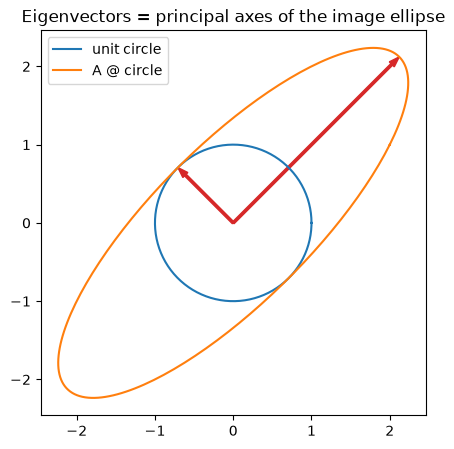

In [5]:
A = np.array([[2., 1.], [1., 2.]])
lam, Q = np.linalg.eigh(A)                 # eigh: for symmetric matrices, eigenvalues in ascending order
print("eigenvalues:", lam)
print("eigenvectors (columns):\n", Q)
print("A q = lambda q:", np.allclose(A @ Q, Q * lam))
print("Q Lambda Q^T reconstructs A:", np.allclose(Q @ np.diag(lam) @ Q.T, A))
print("Q orthogonal:", np.allclose(Q.T @ Q, np.eye(2)))

# Geometric picture: A maps the unit circle to an ellipse with axes along the eigenvectors, lengths = eigenvalues
t = np.linspace(0, 2 * np.pi, 200); circle = np.stack([np.cos(t), np.sin(t)])
ell = A @ circle
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*circle, label="unit circle"); ax.plot(*ell, label="A @ circle")
for l, q in zip(lam, Q.T):
    ax.arrow(0, 0, *(l * q), width=0.03, color="C3", length_includes_head=True)
ax.set_aspect("equal"); ax.legend(); ax.set_title("Eigenvectors = principal axes of the image ellipse"); plt.show()

### 1.4 Singular value decomposition (SVD)

Every matrix $X\in\mathbb{R}^{n\times d}$ (not necessarily square) factorizes as
$$X = U\Sigma V^\top = \sum_{i=1}^r \sigma_i u_i v_i^\top,$$
with $U\in\mathbb{R}^{n\times n}$, $V\in\mathbb{R}^{d\times d}$ orthogonal and $\Sigma$ diagonal with singular values
$\sigma_1\ge\sigma_2\ge\dots\ge\sigma_r>0$ ($r=\operatorname{rank}X$). Connection to eigendecomposition:
$$X^\top X = V\Sigma^\top\Sigma V^\top,\qquad XX^\top = U\Sigma\Sigma^\top U^\top,$$
so the $\sigma_i^2$ are the eigenvalues of $X^\top X$ and the $v_i$ its eigenvectors.

**Eckart–Young theorem.** The best rank-$k$ approximation of $X$ in Frobenius (and spectral) norm is the truncated SVD
$X_k = \sum_{i=1}^k \sigma_i u_i v_i^\top$, with error $\|X-X_k\|_F^2 = \sum_{i>k}\sigma_i^2$. This underlies PCA,
latent semantic analysis and matrix completion. The SVD also gives the **pseudo-inverse**
$X^+ = V\Sigma^+U^\top$ used to solve least squares (Lecture 02).

In [6]:
X = np.array([[3., 2., 2.], [2., 3., -2.]])
U, s, Vt = np.linalg.svd(X, full_matrices=False)
print("singular values:", s)                               # textbook example: 5 and 3
print("U =\n", U, "\nV^T =\n", Vt)
print("reconstruction ok:", np.allclose(U @ np.diag(s) @ Vt, X))
print("sigma^2 vs eigenvalues of X^T X:", s**2, np.linalg.eigvalsh(X.T @ X)[::-1][:2])
print("pseudo-inverse matches np.linalg.pinv:", np.allclose(Vt.T @ np.diag(1 / s) @ U.T, np.linalg.pinv(X)))

singular values: [5. 3.]
U =
 [[-0.7071 -0.7071]
 [-0.7071  0.7071]] 
V^T =
 [[-0.7071 -0.7071 -0.    ]
 [-0.2357  0.2357 -0.9428]]
reconstruction ok: True
sigma^2 vs eigenvalues of X^T X: [25.  9.] [25.  9.]
pseudo-inverse matches np.linalg.pinv: True


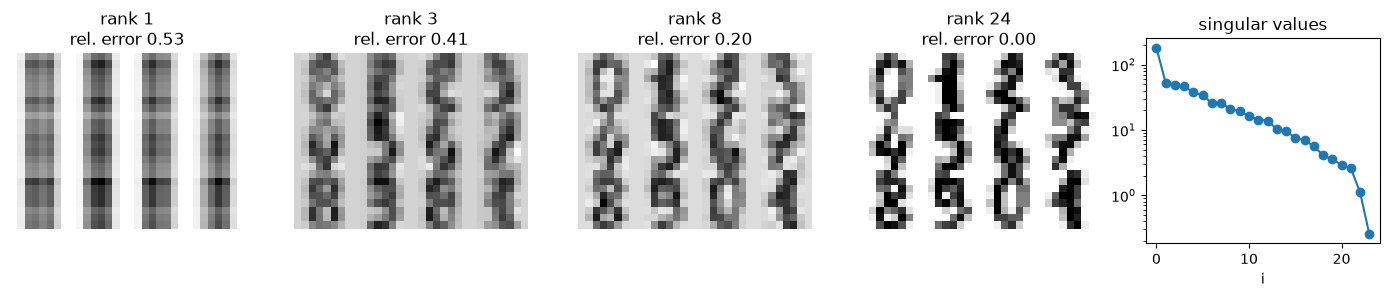

Eckart-Young check (k=8): ||X-X_k||_F^2 = 1868.5230, sum of tail sigma^2 = 1868.5230


In [7]:
# Low-rank approximation of a structured matrix (an 8x8 digit image stacked into a larger 'image')
from sklearn.datasets import load_digits
digits = load_digits()
img = np.block([[digits.images[i + 4 * j] for i in range(4)] for j in range(3)])   # 24x32 mosaic
U, s, Vt = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, k in zip(axes[:4], [1, 3, 8, 24]):
    Xk = U[:, :k] @ np.diag(s[:k]) @ Vt[:k]
    rel = np.linalg.norm(img - Xk) / np.linalg.norm(img)
    ax.imshow(Xk, cmap="gray_r"); ax.set_title(f"rank {k}\nrel. error {rel:.2f}"); ax.axis("off")
axes[4].semilogy(s, "o-"); axes[4].set_title("singular values"); axes[4].set_xlabel("i")
plt.tight_layout(); plt.show()

k = 8
err_fro2 = np.linalg.norm(img - U[:, :k] @ np.diag(s[:k]) @ Vt[:k]) ** 2
print(f"Eckart-Young check (k={k}): ||X-X_k||_F^2 = {err_fro2:.4f}, sum of tail sigma^2 = {np.sum(s[k:]**2):.4f}")

## 2. Multivariate calculus

### 2.1 Gradients

For $f:\mathbb{R}^d\to\mathbb{R}$, the **gradient** $\nabla f(x) = \big(\partial f/\partial x_1,\dots,\partial f/\partial x_d\big)^\top$
points in the direction of steepest ascent, and the first-order Taylor expansion reads
$$f(x+\delta) = f(x) + \nabla f(x)^\top\delta + O(\|\delta\|^2).$$
At a local minimum of a differentiable function, $\nabla f(x)=0$.

**Matrix-calculus identities** (derive each by writing the sum in coordinates):

| $f(x)$ | $\nabla_x f$ |
|---|---|
| $a^\top x$ | $a$ |
| $x^\top A x$ | $(A + A^\top)x$  ($=2Ax$ if $A$ symmetric) |
| $\|Ax-b\|_2^2$ | $2A^\top(Ax-b)$ |
| $\log\sum_i e^{x_i}$ | $\operatorname{softmax}(x)$ |

*Derivation of the second row:* $x^\top A x = \sum_{i,j}A_{ij}x_ix_j$, so
$\partial/\partial x_k = \sum_j A_{kj}x_j + \sum_i A_{ik}x_i = (Ax)_k + (A^\top x)_k$.
The third row then follows from $\|Ax-b\|^2 = x^\top A^\top A x - 2b^\top A x + b^\top b$.

### 2.2 Jacobian and chain rule

For $g:\mathbb{R}^n\to\mathbb{R}^m$, the **Jacobian** $J_g(x)\in\mathbb{R}^{m\times n}$ has entries $\partial g_i/\partial x_j$.
For a composition $h = f\circ g$ the **chain rule** is a product of Jacobians:
$$J_{f\circ g}(x) = J_f\big(g(x)\big)\,J_g(x).$$
For scalar $f$, $\nabla_x (f\circ g) = J_g(x)^\top \nabla f(g(x))$. Evaluating such products from the output backwards
is exactly **backpropagation** (reverse-mode automatic differentiation).

*Example:* the logistic-regression loss for one point, $L(w) = -y\log\sigma(w^\top x) - (1-y)\log(1-\sigma(w^\top x))$,
with $z=w^\top x$ and $\sigma'(z)=\sigma(z)(1-\sigma(z))$, gives by the chain rule
$$\nabla_w L = \frac{\partial L}{\partial z}\,\nabla_w z = \big(\sigma(z)-y\big)\,x .$$

### 2.3 Numerical gradient checking

The **central difference**
$$\frac{\partial f}{\partial x_i}(x) \approx \frac{f(x + h e_i) - f(x - h e_i)}{2h}$$
has error $O(h^2)$ (the forward difference only $O(h)$), but too small $h$ amplifies floating-point round-off (error
$\sim \epsilon_{\text{mach}}/h$). With $h\approx 10^{-5}$ in double precision we expect relative errors around
$10^{-9}$–$10^{-11}$. Always check hand-derived gradients this way before trusting an optimizer.

In [8]:
def numerical_grad(f, x, h=1e-5):
    # central-difference gradient of a scalar function f at x
    g = np.zeros_like(x, dtype=float)
    for i in range(x.size):
        e = np.zeros_like(x, dtype=float); e[i] = h
        g[i] = (f(x + e) - f(x - e)) / (2 * h)
    return g

def rel_error(a, b):
    return np.linalg.norm(a - b) / max(np.linalg.norm(a) + np.linalg.norm(b), 1e-15)

d = 5
A = rng.normal(size=(d, d)); b = rng.normal(size=d); M = rng.normal(size=(8, d)); c = rng.normal(size=8)
x0 = rng.normal(size=d)

checks = {
    "x^T A x":         (lambda x: x @ A @ x,                       lambda x: (A + A.T) @ x),
    "||Mx - c||^2":    (lambda x: np.sum((M @ x - c) ** 2),        lambda x: 2 * M.T @ (M @ x - c)),
    "logsumexp(x)":    (lambda x: np.log(np.sum(np.exp(x))),       lambda x: np.exp(x) / np.sum(np.exp(x))),
}
for name, (f, grad) in checks.items():
    print(f"{name:15s} relative error analytic vs numeric: {rel_error(grad(x0), numerical_grad(f, x0)):.2e}")

# Logistic loss via chain rule
sigmoid = lambda z: 1 / (1 + np.exp(-z))
xi, yi = rng.normal(size=d), 1.0
L = lambda w: -yi * np.log(sigmoid(w @ xi)) - (1 - yi) * np.log(1 - sigmoid(w @ xi))
print(f"{'logistic loss':15s} relative error analytic vs numeric: {rel_error((sigmoid(x0 @ xi) - yi) * xi, numerical_grad(L, x0)):.2e}")

x^T A x         relative error analytic vs numeric: 3.69e-12
||Mx - c||^2    relative error analytic vs numeric: 4.85e-12
logsumexp(x)    relative error analytic vs numeric: 6.72e-12
logistic loss   relative error analytic vs numeric: 1.48e-11


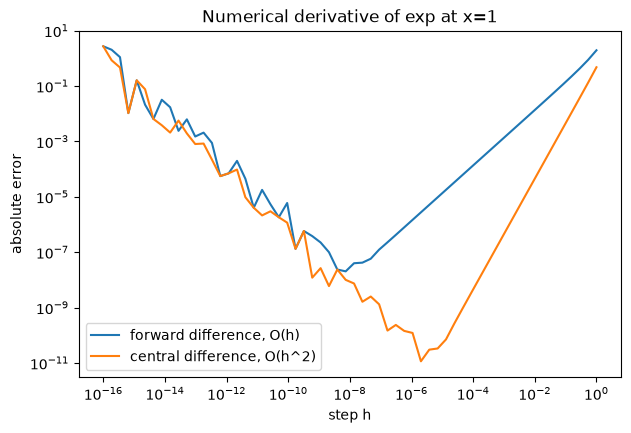

best h (central): 2.0e-06; best h (forward): 7.3e-09


In [9]:
# Error of finite differences as a function of step size h: truncation vs round-off trade-off
f = np.exp; x_pt = 1.0; true = np.exp(1.0)
hs = np.logspace(-16, 0, 60)
fwd = np.abs((f(x_pt + hs) - f(x_pt)) / hs - true)
ctr = np.abs((f(x_pt + hs) - f(x_pt - hs)) / (2 * hs) - true)
plt.loglog(hs, fwd, label="forward difference, O(h)")
plt.loglog(hs, ctr, label="central difference, O(h^2)")
plt.xlabel("step h"); plt.ylabel("absolute error"); plt.title("Numerical derivative of exp at x=1")
plt.legend(); plt.show()
print(f"best h (central): {hs[np.argmin(ctr)]:.1e}; best h (forward): {hs[np.argmin(fwd)]:.1e}")

In [10]:
# Jacobian and chain rule, verified numerically.
# g: R^3 -> R^2, g(x) = (x0*x1, sin(x2) + x0^2);  f: R^2 -> R, f(u) = u0^2 + 3 u1
def g(x): return np.array([x[0] * x[1], np.sin(x[2]) + x[0] ** 2])
def J_g(x): return np.array([[x[1], x[0], 0.0], [2 * x[0], 0.0, np.cos(x[2])]])
def f(u): return u[0] ** 2 + 3 * u[1]
def grad_f(u): return np.array([2 * u[0], 3.0])

xq = np.array([0.5, -1.2, 0.3])
J_num = np.stack([numerical_grad(lambda x, i=i: g(x)[i], xq) for i in range(2)])
print("Jacobian analytic:\n", J_g(xq), "\nJacobian numeric:\n", J_num)
chain = J_g(xq).T @ grad_f(g(xq))                  # nabla (f o g) = J_g^T nabla f
print("chain-rule gradient:", chain, "| numeric:", numerical_grad(lambda x: f(g(x)), xq))

Jacobian analytic:
 [[-1.2     0.5     0.    ]
 [ 1.      0.      0.9553]] 
Jacobian numeric:
 [[-1.2     0.5     0.    ]
 [ 1.      0.      0.9553]]
chain-rule gradient: [ 4.44  -0.6    2.866] | numeric: [ 4.44  -0.6    2.866]


## 3. Probability and statistics

### 3.1 Random variables, expectation, variance

A random variable $X$ has a distribution described by a pmf $p(x)$ (discrete) or density $p(x)$ (continuous).
$$\mathbb{E}[X] = \int x\,p(x)\,dx,\qquad \mathrm{Var}[X] = \mathbb{E}\big[(X-\mathbb{E}X)^2\big] = \mathbb{E}[X^2]-(\mathbb{E}X)^2 .$$
Properties: expectation is **linear**, $\mathbb{E}[aX+bY] = a\mathbb{E}X + b\mathbb{E}Y$ (always);
$\mathrm{Var}[aX+b] = a^2\mathrm{Var}X$; $\mathrm{Var}[X+Y] = \mathrm{Var}X + \mathrm{Var}Y + 2\,\mathrm{Cov}(X,Y)$.
For a random vector, $\mathrm{Cov}[X] = \mathbb{E}[(X-\mu)(X-\mu)^\top]$ and $\mathrm{Cov}[AX] = A\,\mathrm{Cov}[X]A^\top$.

The **law of large numbers** says the sample mean $\bar X_n\to\mathbb{E}X$, and the **central limit theorem**
says $\sqrt{n}(\bar X_n-\mu)\xrightarrow{d}\mathcal{N}(0,\sigma^2)$ — the reason Gaussians are everywhere.

E[X]  : MC 0.4996  vs exact 0.5
Var[X]: MC 0.2507  vs exact 0.25


Cov[AX] MC:
 [[ 4.5962 -0.791 ]
 [-0.791   2.7936]] 
A Sigma A^T:
 [[ 4.6 -0.8]
 [-0.8  2.8]]


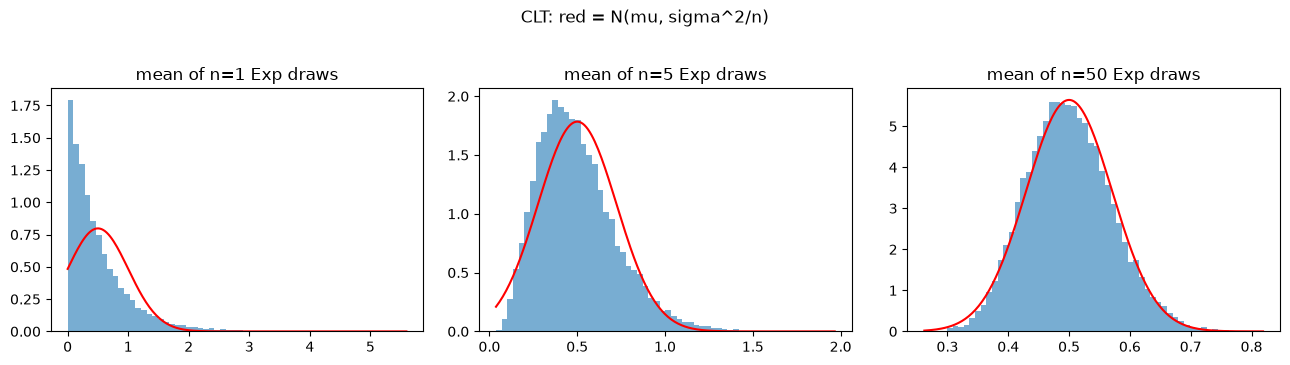

In [11]:
# Monte Carlo check of E and Var for an exponential(rate=2) variable: E = 1/2, Var = 1/4
samples = rng.exponential(scale=0.5, size=200_000)
print(f"E[X]  : MC {samples.mean():.4f}  vs exact 0.5")
print(f"Var[X]: MC {samples.var():.4f}  vs exact 0.25")

# Linearity & Cov[AX] = A Cov[X] A^T
Sigma = np.array([[2.0, 0.8], [0.8, 1.0]])
Z = rng.multivariate_normal([0, 0], Sigma, size=200_000)
Amat = np.array([[1.0, 1.0], [1.0, -2.0]])
print("Cov[AX] MC:\n", np.cov((Z @ Amat.T).T), "\nA Sigma A^T:\n", Amat @ Sigma @ Amat.T)

# Central limit theorem: means of n exponential draws
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, n in zip(axes, [1, 5, 50]):
    means = rng.exponential(0.5, size=(20_000, n)).mean(1)
    ax.hist(means, bins=60, density=True, alpha=0.6)
    grid = np.linspace(means.min(), means.max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, 0.5, 0.5 / np.sqrt(n)), "r")
    ax.set_title(f"mean of n={n} Exp draws")
plt.suptitle("CLT: red = N(mu, sigma^2/n)", y=1.03); plt.tight_layout(); plt.show()

### 3.2 The Gaussian distribution

Univariate: $\mathcal{N}(x\mid\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\big(-\frac{(x-\mu)^2}{2\sigma^2}\big)$.

Multivariate, $x\in\mathbb{R}^d$, with mean $\mu$ and symmetric positive-definite covariance $\Sigma$:
$$\mathcal{N}(x\mid\mu,\Sigma) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}\exp\!\Big(-\tfrac12 (x-\mu)^\top\Sigma^{-1}(x-\mu)\Big).$$
Level sets are ellipsoids whose axes are the eigenvectors of $\Sigma$, with semi-axis lengths $\propto\sqrt{\lambda_i}$
(linking back to Section 1.3). Sampling: if $z\sim\mathcal{N}(0,I)$ and $\Sigma = LL^\top$ (Cholesky), then
$\mu + Lz\sim\mathcal{N}(\mu,\Sigma)$. Gaussians are closed under affine maps, marginalization and conditioning.

sample mean: [ 0.9979 -0.5048] | sample cov:
 [[1.4892 0.9117]
 [0.9117 1.0438]]
matches scipy: True


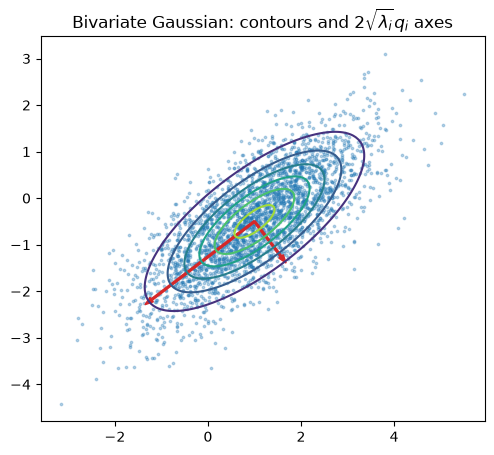

In [12]:
mu = np.array([1.0, -0.5]); Sigma = np.array([[1.5, 0.9], [0.9, 1.0]])
L = np.linalg.cholesky(Sigma)
S = mu + rng.normal(size=(3000, 2)) @ L.T                  # samples via Cholesky
print("sample mean:", S.mean(0), "| sample cov:\n", np.cov(S.T))

def gauss_pdf(X, mu, Sigma):
    d = len(mu); diff = X - mu
    maha = np.einsum("ni,ij,nj->n", diff, np.linalg.inv(Sigma), diff)   # squared Mahalanobis distances
    return np.exp(-0.5 * maha) / np.sqrt((2 * np.pi) ** d * np.linalg.det(Sigma))

g1, g2 = np.meshgrid(np.linspace(-3, 5, 150), np.linspace(-4, 3, 150))
grid = np.column_stack([g1.ravel(), g2.ravel()])
dens = gauss_pdf(grid, mu, Sigma)
print("matches scipy:", np.allclose(dens, stats.multivariate_normal(mu, Sigma).pdf(grid)))

lam, Q = np.linalg.eigh(Sigma)
plt.figure(figsize=(6, 5))
plt.scatter(S[:, 0], S[:, 1], s=3, alpha=0.3)
plt.contour(g1, g2, dens.reshape(g1.shape), levels=6, cmap="viridis")
for l, q in zip(lam, Q.T):
    plt.arrow(*mu, *(2 * np.sqrt(l) * q), width=0.04, color="C3", length_includes_head=True)
plt.gca().set_aspect("equal"); plt.title(r"Bivariate Gaussian: contours and $2\sqrt{\lambda_i}q_i$ axes"); plt.show()

### 3.3 Bayes' rule

From $p(a,b) = p(a\mid b)p(b) = p(b\mid a)p(a)$:
$$p(\theta\mid\mathcal{D}) = \frac{p(\mathcal{D}\mid\theta)\,p(\theta)}{p(\mathcal{D})}\qquad
\text{posterior} = \frac{\text{likelihood}\times\text{prior}}{\text{evidence}}, \quad p(\mathcal{D}) = \int p(\mathcal{D}\mid\theta)p(\theta)d\theta.$$

**Worked example (diagnostic test).** A disease has prevalence $1\%$. A test has sensitivity
$P(+\mid D)=0.95$ and specificity $P(-\mid \neg D)=0.90$. Then
$$P(D\mid +) = \frac{0.95\cdot0.01}{0.95\cdot0.01 + 0.10\cdot0.99} = \frac{0.0095}{0.1085}\approx 0.088 .$$
Despite a "95% accurate" test, a positive result means less than 9% chance of disease — the **base-rate fallacy**.
The same reasoning explains why accuracy is misleading on imbalanced classification problems.

P(D | +) exact = 0.0876
P(D | +) simulated = 0.0877


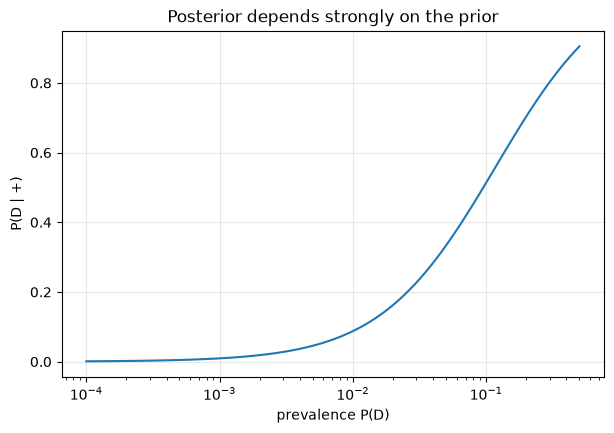

In [13]:
prev, sens, spec = 0.01, 0.95, 0.90
posterior = sens * prev / (sens * prev + (1 - spec) * (1 - prev))
print(f"P(D | +) exact = {posterior:.4f}")

# Simulation of one million patients
N = 1_000_000
disease = rng.random(N) < prev
positive = np.where(disease, rng.random(N) < sens, rng.random(N) < 1 - spec)
print(f"P(D | +) simulated = {disease[positive].mean():.4f}")

prevs = np.logspace(-4, -0.3, 100)
post = sens * prevs / (sens * prevs + (1 - spec) * (1 - prevs))
plt.semilogx(prevs, post); plt.xlabel("prevalence P(D)"); plt.ylabel("P(D | +)")
plt.title("Posterior depends strongly on the prior"); plt.grid(alpha=0.3); plt.show()

## 4. Estimation: MLE and MAP

### 4.1 Maximum likelihood for a Gaussian — derivation

Let $x_1,\dots,x_n\overset{\text{iid}}{\sim}\mathcal{N}(\mu,\sigma^2)$. The **likelihood** is
$L(\mu,\sigma^2) = \prod_i \mathcal{N}(x_i\mid\mu,\sigma^2)$ and the log-likelihood
$$\ell(\mu,\sigma^2) = -\frac n2\log(2\pi) - \frac n2\log\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2 .$$
Setting derivatives to zero:
$$\frac{\partial\ell}{\partial\mu} = \frac{1}{\sigma^2}\sum_i (x_i-\mu) = 0 \ \Longrightarrow\ \hat\mu_{\text{MLE}} = \frac1n\sum_i x_i = \bar x,$$
$$\frac{\partial\ell}{\partial\sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_i (x_i-\mu)^2 = 0 \ \Longrightarrow\ \hat\sigma^2_{\text{MLE}} = \frac1n\sum_i (x_i-\bar x)^2 .$$
(The Hessian at this point is negative definite, so it is a maximum.)

**Bias.** $\hat\mu$ is unbiased. For the variance, using $\sum_i(x_i-\bar x)^2 = \sum_i (x_i-\mu)^2 - n(\bar x-\mu)^2$,
$$\mathbb{E}[\hat\sigma^2_{\text{MLE}}] = \frac1n\big(n\sigma^2 - n\cdot\tfrac{\sigma^2}{n}\big) = \frac{n-1}{n}\sigma^2,$$
so the MLE underestimates the variance; dividing by $n-1$ (Bessel's correction) gives an unbiased estimator.
Both estimators are **consistent**: they converge to the truth as $n\to\infty$. Also $\mathrm{Var}[\hat\mu]=\sigma^2/n$.

Note the link to ML: maximizing a Gaussian likelihood in $\mu$ is the same as **minimizing squared error** — the
probabilistic justification of least squares in Lecture 02.

In [14]:
mu_true, sigma2_true = 2.0, 4.0

# (1) Verify the closed form against a numerical maximizer of the log-likelihood
from scipy.optimize import minimize
data = rng.normal(mu_true, np.sqrt(sigma2_true), size=50)
nll = lambda p: -np.sum(stats.norm.logpdf(data, p[0], np.exp(p[1])))      # parametrize sigma = exp(s) > 0
res = minimize(nll, x0=[0.0, 0.0])
print(f"closed form : mu = {data.mean():.4f}, sigma^2 = {data.var(ddof=0):.4f}")
print(f"numerical   : mu = {res.x[0]:.4f}, sigma^2 = {np.exp(res.x[1])**2:.4f}")

# (2) Bias of the variance MLE: average over many repeated datasets of size n
for n in [2, 5, 20, 100]:
    D = rng.normal(mu_true, np.sqrt(sigma2_true), size=(100_000, n))
    print(f"n={n:3d}:  E[mu_hat]={D.mean(1).mean():.3f}   E[sigma2_MLE]={D.var(1, ddof=0).mean():.3f} "
          f"(theory {(n-1)/n*sigma2_true:.3f})   E[sigma2_unbiased]={D.var(1, ddof=1).mean():.3f}   Var[mu_hat]={D.mean(1).var():.4f} (theory {sigma2_true/n:.4f})")

closed form : mu = 2.0240, sigma^2 = 4.5186
numerical   : mu = 2.0240, sigma^2 = 4.5186


n=  2:  E[mu_hat]=2.003   E[sigma2_MLE]=2.009 (theory 2.000)   E[sigma2_unbiased]=4.018   Var[mu_hat]=1.9963 (theory 2.0000)
n=  5:  E[mu_hat]=2.002   E[sigma2_MLE]=3.206 (theory 3.200)   E[sigma2_unbiased]=4.007   Var[mu_hat]=0.7975 (theory 0.8000)


n= 20:  E[mu_hat]=1.998   E[sigma2_MLE]=3.798 (theory 3.800)   E[sigma2_unbiased]=3.998   Var[mu_hat]=0.1990 (theory 0.2000)


n=100:  E[mu_hat]=1.999   E[sigma2_MLE]=3.959 (theory 3.960)   E[sigma2_unbiased]=3.999   Var[mu_hat]=0.0398 (theory 0.0400)


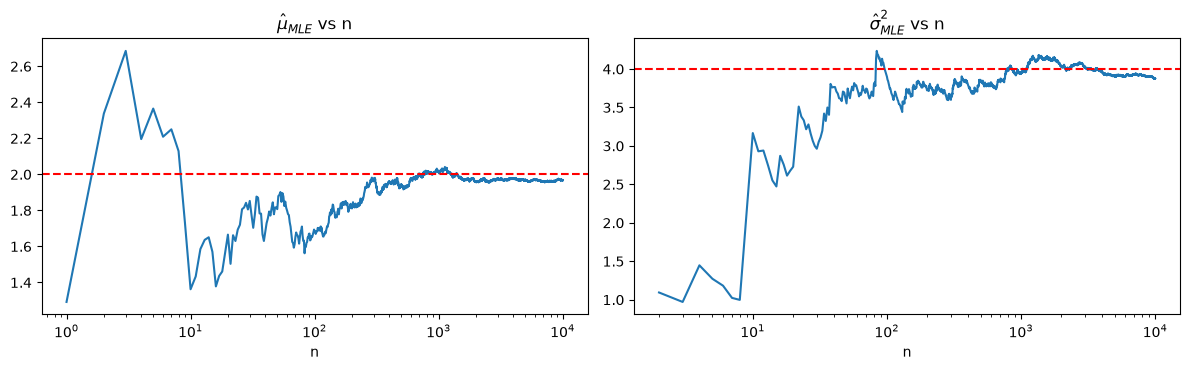

In [15]:
# (3) Consistency: estimates along a growing sample
stream = rng.normal(mu_true, np.sqrt(sigma2_true), size=10_000)
ns = np.arange(1, len(stream) + 1)
run_mean = np.cumsum(stream) / ns
run_var = np.cumsum(stream**2) / ns - run_mean**2
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].semilogx(ns, run_mean); axes[0].axhline(mu_true, color="r", ls="--"); axes[0].set_title(r"$\hat\mu_{MLE}$ vs n")
axes[1].semilogx(ns[1:], run_var[1:]); axes[1].axhline(sigma2_true, color="r", ls="--"); axes[1].set_title(r"$\hat\sigma^2_{MLE}$ vs n")
for ax in axes: ax.set_xlabel("n")
plt.tight_layout(); plt.show()

### 4.2 Maximum a posteriori (MAP)

MAP maximizes the posterior instead of the likelihood:
$$\hat\theta_{\text{MAP}} = \arg\max_\theta\ \log p(\mathcal{D}\mid\theta) + \log p(\theta).$$
The log-prior acts as a **regularizer**. For the Gaussian mean with known $\sigma^2$ and prior $\mu\sim\mathcal{N}(\mu_0,\tau^2)$:
$$-\log p(\mu\mid\mathcal{D}) = \frac{1}{2\sigma^2}\sum_i (x_i-\mu)^2 + \frac{1}{2\tau^2}(\mu-\mu_0)^2 + \text{const}.$$
Setting the derivative to zero,
$$\hat\mu_{\text{MAP}} = \frac{\frac{n}{\sigma^2}\bar x + \frac{1}{\tau^2}\mu_0}{\frac{n}{\sigma^2}+\frac{1}{\tau^2}},$$
a precision-weighted average of the data mean and the prior mean. Here the posterior is itself Gaussian (conjugacy)
with variance $\big(n/\sigma^2 + 1/\tau^2\big)^{-1}$, so MAP = posterior mean. As $n\to\infty$ the data dominate and
$\hat\mu_{\text{MAP}}\to\hat\mu_{\text{MLE}}$; for small $n$, MAP **shrinks** toward $\mu_0$, trading bias for variance.
With $\mu_0=0$ this is exactly the mechanism behind Ridge regression.

In [16]:
sigma2, mu0, tau2 = sigma2_true, 0.0, 1.0
def mu_map(x): n = len(x); return (n / sigma2 * x.mean() + mu0 / tau2) / (n / sigma2 + 1 / tau2)

# Compare MSE of MLE vs MAP over repeated small samples, for a true mean near / far from the prior mean
for mu_star in [0.5, 2.0, 5.0]:
    for n in [3, 30]:
        D = rng.normal(mu_star, np.sqrt(sigma2), size=(20_000, n))
        mle = D.mean(1)
        mp = (n / sigma2 * mle + mu0 / tau2) / (n / sigma2 + 1 / tau2)
        print(f"mu*={mu_star:3.1f} n={n:2d}:  MSE(MLE)={np.mean((mle-mu_star)**2):.3f}  MSE(MAP)={np.mean((mp-mu_star)**2):.3f}")

mu*=0.5 n= 3:  MSE(MLE)=1.326  MSE(MAP)=0.325
mu*=0.5 n=30:  MSE(MLE)=0.135  MSE(MAP)=0.108
mu*=2.0 n= 3:  MSE(MLE)=1.342  MSE(MAP)=1.560
mu*=2.0 n=30:  MSE(MLE)=0.133  MSE(MAP)=0.160
mu*=5.0 n= 3:  MSE(MLE)=1.347  MSE(MAP)=8.399
mu*=5.0 n=30:  MSE(MLE)=0.132  MSE(MAP)=0.447


MAP wins clearly when the prior is well placed ($\mu^\star$ close to $\mu_0=0$) and $n$ is small, and loses when the
prior is badly misplaced ($\mu^\star=5$, several prior standard deviations away): shrinkage reduces variance at the cost
of bias. As $n$ grows the two estimators converge.

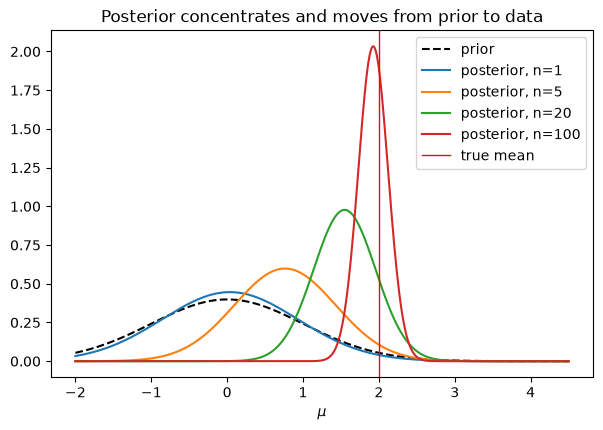

In [17]:
# Posterior of mu after observing n points: prior N(0,1), likelihood variance 4, true mu = 2
grid = np.linspace(-2, 4.5, 400)
data = rng.normal(2.0, 2.0, size=100)
plt.plot(grid, stats.norm.pdf(grid, mu0, np.sqrt(tau2)), "k--", label="prior")
for n in [1, 5, 20, 100]:
    x = data[:n]; post_var = 1 / (n / sigma2 + 1 / tau2)
    plt.plot(grid, stats.norm.pdf(grid, mu_map(x), np.sqrt(post_var)), label=f"posterior, n={n}")
plt.axvline(2.0, color="r", lw=1, label="true mean")
plt.xlabel(r"$\mu$"); plt.title("Posterior concentrates and moves from prior to data"); plt.legend(); plt.show()

## 5. Optimization

Training an ML model almost always means solving $\min_\theta J(\theta)$ for a loss $J$.

### 5.1 Convexity

A set $C$ is convex if it contains every segment between its points. A function $f$ is **convex** if
$$f(\lambda x + (1-\lambda)y) \le \lambda f(x) + (1-\lambda) f(y)\qquad \forall x,y,\ \lambda\in[0,1].$$
Equivalent characterizations for differentiable $f$: $f(y)\ge f(x) + \nabla f(x)^\top(y-x)$ (the tangent plane
is a global under-estimator); for twice-differentiable $f$: the Hessian $\nabla^2 f(x)\succeq 0$ everywhere.
**Every local minimum of a convex function is global**, and the set of minimizers is convex. Least squares, Ridge,
Lasso, logistic regression and SVMs are convex; neural networks are not.

$f$ is **$\mu$-strongly convex** and **$L$-smooth** if $\mu I \preceq \nabla^2 f \preceq L I$; the ratio
$\kappa = L/\mu$ is the condition number.

### 5.2 Gradient descent

$$\theta_{t+1} = \theta_t - \eta\,\nabla J(\theta_t).$$
**Analysis on a quadratic.** Take $J(\theta) = \tfrac12\theta^\top A\theta$ with $A = Q\Lambda Q^\top\succ 0$. Then
$\theta_{t+1} = (I-\eta A)\theta_t$, and in the eigenbasis each coordinate evolves independently:
$$\tilde\theta_{t,i} = (1-\eta\lambda_i)^t\,\tilde\theta_{0,i}.$$
Hence:

- GD **converges iff** $|1-\eta\lambda_i|<1$ for all $i$, i.e. $0<\eta<2/\lambda_{\max}$; beyond that it diverges.
- The slowest direction has rate $\max_i|1-\eta\lambda_i|$; the best fixed step $\eta^\star = 2/(\lambda_{\max}+\lambda_{\min})$
  gives rate $\frac{\kappa-1}{\kappa+1}$. **Ill-conditioning** ($\kappa\gg1$) makes GD zig-zag and crawl — the reason
  feature scaling matters.
- For general $L$-smooth convex $f$ with $\eta = 1/L$: $f(\theta_t)-f^\star \le \frac{L\|\theta_0-\theta^\star\|^2}{2t}$;
  with strong convexity the convergence is linear (geometric).

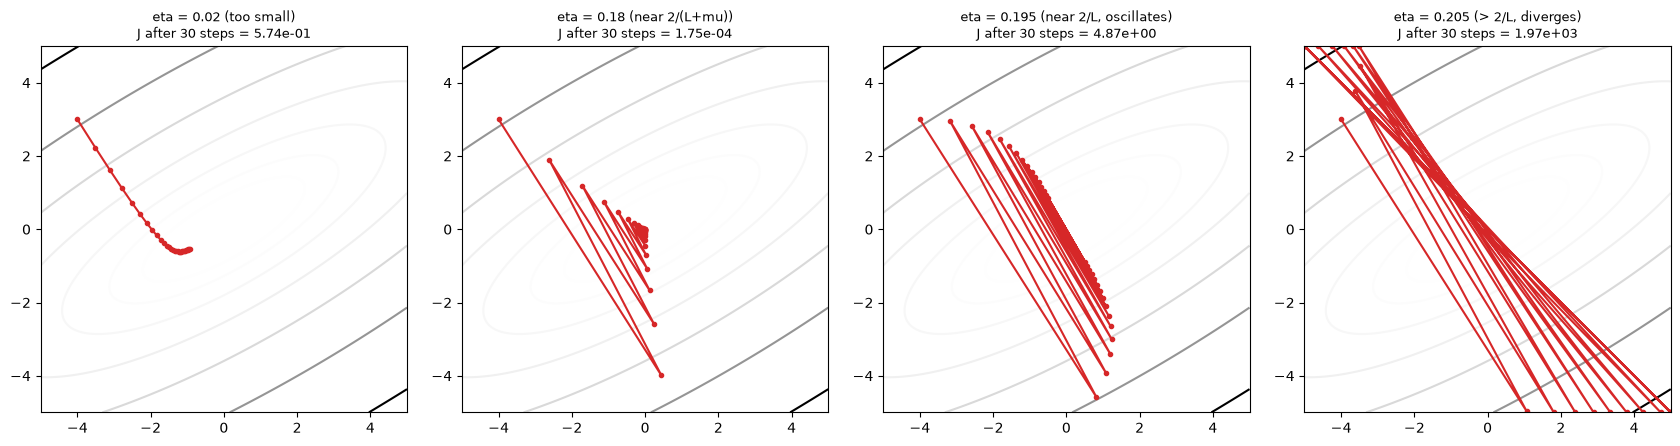

theory: stable iff eta < 2/lambda_max = 0.2 | optimal eta* = 2/(L+mu) = 0.1818


In [18]:
# 2-D quadratic J(theta) = 0.5 theta^T A theta with eigenvalues 1 and 10 (kappa = 10), rotated 30 degrees
rot = np.deg2rad(30); R = np.array([[np.cos(rot), -np.sin(rot)], [np.sin(rot), np.cos(rot)]])
A = R @ np.diag([1.0, 10.0]) @ R.T
J = lambda th: 0.5 * np.einsum("...i,ij,...j->...", th, A, th)
gradJ = lambda th: A @ th

def gd(grad, theta0, lr, n_steps):
    path = [theta0]
    for _ in range(n_steps):
        path.append(path[-1] - lr * grad(path[-1]))
    return np.array(path)

theta0 = np.array([-4.0, 3.0])
lam_max = 10.0
lrs = {"eta = 0.02 (too small)": 0.02, "eta = 0.18 (near 2/(L+mu))": 0.18,
       "eta = 0.195 (near 2/L, oscillates)": 0.195, "eta = 0.205 (> 2/L, diverges)": 0.205}

g1, g2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
Jgrid = J(np.stack([g1, g2], axis=-1))
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (name, lr) in zip(axes, lrs.items()):
    path = gd(gradJ, theta0, lr, 30)
    ax.contour(g1, g2, Jgrid, levels=np.logspace(-1, 2.3, 12), cmap="Greys")
    p = np.clip(path, -5, 5)
    ax.plot(p[:, 0], p[:, 1], "o-", ms=3, color="C3")
    ax.set_title(f"{name}\nJ after 30 steps = {J(path[-1]):.2e}", fontsize=9)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print("theory: stable iff eta < 2/lambda_max =", 2 / lam_max, "| optimal eta* = 2/(L+mu) =", round(2 / 11, 4))

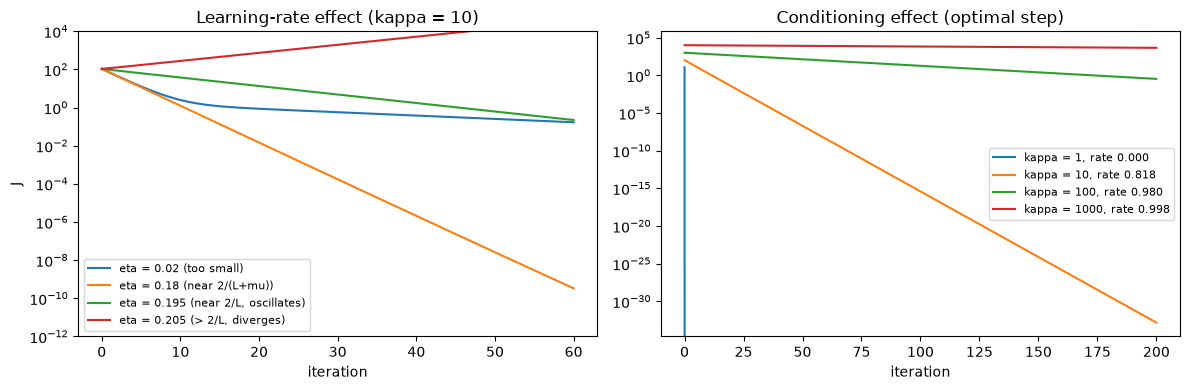

In [19]:
# Convergence curves: effect of the learning rate and of conditioning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, lr in lrs.items():
    path = gd(gradJ, theta0, lr, 60)
    axes[0].semilogy([J(p) for p in path], label=name)
axes[0].set_ylim(1e-12, 1e4); axes[0].set_xlabel("iteration"); axes[0].set_ylabel("J"); axes[0].legend(fontsize=8)
axes[0].set_title("Learning-rate effect (kappa = 10)")

for kappa in [1, 10, 100, 1000]:
    Ak = R @ np.diag([1.0, kappa]) @ R.T
    lr = 2 / (1 + kappa)                           # optimal fixed step
    path = gd(lambda th: Ak @ th, theta0, lr, 200)
    axes[1].semilogy([0.5 * p @ Ak @ p for p in path], label=f"kappa = {kappa}, rate {(kappa-1)/(kappa+1):.3f}")
axes[1].set_xlabel("iteration"); axes[1].set_title("Conditioning effect (optimal step)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.3 Stochastic gradient descent and momentum

In ML the objective is an average over data, $J(\theta) = \frac1n\sum_{i=1}^n \ell_i(\theta)$. A full gradient costs
$O(n)$. **SGD** uses an unbiased estimate from a random mini-batch $B$:
$$g_t = \frac{1}{|B|}\sum_{i\in B}\nabla\ell_i(\theta_t),\qquad \mathbb{E}[g_t] = \nabla J(\theta_t),\qquad \theta_{t+1} = \theta_t - \eta_t g_t .$$
The noise in $g_t$ (variance $\propto 1/|B|$) prevents convergence with a constant step: iterates hover in a ball of
radius $O(\eta)$ around the optimum. Convergence requires a decaying schedule with $\sum_t\eta_t=\infty$,
$\sum_t\eta_t^2<\infty$ (Robbins–Monro), e.g. $\eta_t\propto 1/t$. In practice SGD's cheap iterations win when $n$ is large.

**Momentum (heavy ball, Polyak 1964)** accumulates a velocity that damps oscillations across steep directions and
accelerates along shallow ones:
$$v_{t+1} = \beta v_t + \nabla J(\theta_t),\qquad \theta_{t+1} = \theta_t - \eta\, v_{t+1}.$$
On quadratics with tuned $\eta,\beta$ the rate improves from $\frac{\kappa-1}{\kappa+1}$ to $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$.
Nesterov's accelerated gradient evaluates the gradient at the look-ahead point $\theta_t-\eta\beta v_t$.

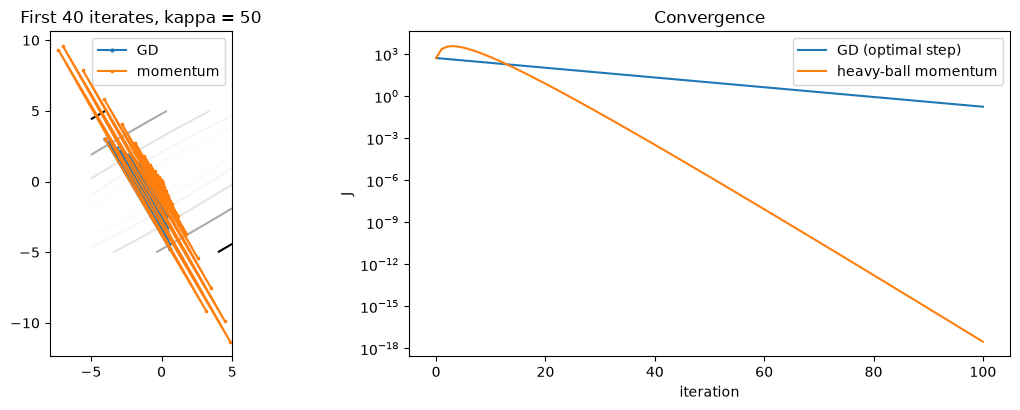

In [20]:
# Momentum vs plain GD on an ill-conditioned quadratic (kappa = 50)
kappa = 50.0
Ak = R @ np.diag([1.0, kappa]) @ R.T
gK = lambda th: Ak @ th
JK = lambda th: 0.5 * th @ Ak @ th

def gd_momentum(grad, theta0, lr, beta, n_steps):
    th, v, path = theta0.copy(), np.zeros_like(theta0), [theta0]
    for _ in range(n_steps):
        v = beta * v + grad(th)
        th = th - lr * v
        path.append(th)
    return np.array(path)

L_, mu_ = kappa, 1.0
lr_hb = 4 / (np.sqrt(L_) + np.sqrt(mu_)) ** 2                                   # Polyak's tuned parameters
beta_hb = ((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)) ** 2
p_gd = gd(gK, theta0, 2 / (L_ + mu_), 100)
p_hb = gd_momentum(gK, theta0, lr_hb, beta_hb, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
G = np.stack(np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200)), -1)
axes[0].contour(G[..., 0], G[..., 1], 0.5 * np.einsum("...i,ij,...j->...", G, Ak, G), levels=np.logspace(-1, 3, 12), cmap="Greys")
axes[0].plot(*p_gd[:40].T, "o-", ms=2, label="GD"); axes[0].plot(*p_hb[:40].T, "s-", ms=2, label="momentum")
axes[0].set_aspect("equal"); axes[0].legend(); axes[0].set_title("First 40 iterates, kappa = 50")
axes[1].semilogy([JK(p) for p in p_gd], label="GD (optimal step)")
axes[1].semilogy([JK(p) for p in p_hb], label="heavy-ball momentum")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("J"); axes[1].legend(); axes[1].set_title("Convergence")
plt.tight_layout(); plt.show()

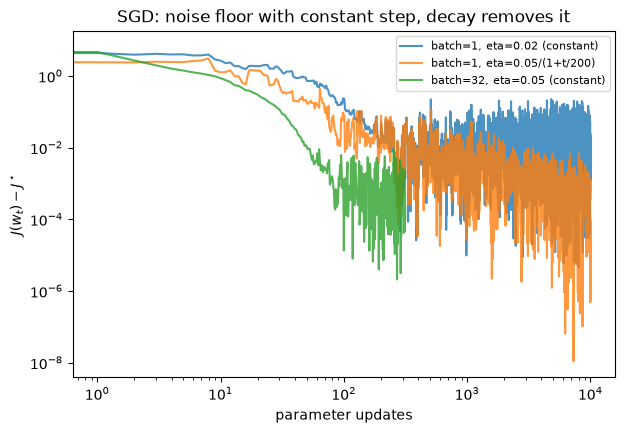

batch=1, eta=0.02 (constant)     final suboptimality 4.05e-03
batch=1, eta=0.05/(1+t/200)      final suboptimality 1.13e-05
batch=32, eta=0.05 (constant)    final suboptimality 1.01e-04


In [21]:
# SGD on a least-squares problem J(w) = 1/(2n) ||Xw - y||^2: constant vs decaying step, and batch size
n, d = 2000, 2
Xs = rng.normal(size=(n, d)) * np.array([1.0, 3.0])
w_true = np.array([2.0, -1.0])
ys = Xs @ w_true + rng.normal(0, 0.5, n)
w_star = np.linalg.lstsq(Xs, ys, rcond=None)[0]
Jls = lambda w: 0.5 * np.mean((Xs @ w - ys) ** 2)

def sgd(lr_fn, batch, n_epochs=5, seed=0):
    r = np.random.default_rng(seed); w = np.zeros(d); hist = [Jls(w)]; t = 0
    for _ in range(n_epochs):
        perm = r.permutation(n)
        for s in range(0, n, batch):
            idx = perm[s:s + batch]
            g = Xs[idx].T @ (Xs[idx] @ w - ys[idx]) / len(idx)      # mini-batch gradient
            w -= lr_fn(t) * g; t += 1
            hist.append(Jls(w))
    return np.array(hist)

J_star = Jls(w_star)
runs = {
    "batch=1, eta=0.02 (constant)": sgd(lambda t: 0.02, 1),
    "batch=1, eta=0.05/(1+t/200)": sgd(lambda t: 0.05 / (1 + t / 200), 1),
    "batch=32, eta=0.05 (constant)": sgd(lambda t: 0.05, 32),
}
for name, h in runs.items():
    plt.semilogy(np.arange(len(h)), h - J_star + 1e-12, label=name, alpha=0.8)
plt.xscale("log"); plt.xlabel("parameter updates"); plt.ylabel(r"$J(w_t) - J^\star$")
plt.title("SGD: noise floor with constant step, decay removes it"); plt.legend(fontsize=8); plt.show()
for name, h in runs.items():
    print(f"{name:32s} final suboptimality {h[-1] - J_star:.2e}")

## 6. Pitfalls & practical tips

- **Never invert matrices** to solve systems; use `solve`, `lstsq`, Cholesky or QR. Use `eigh` (not `eig`) for symmetric
  matrices: it is faster, guarantees real output and orthonormal eigenvectors.
- **Numerical stability**: compute $\log\sum e^{x_i}$ as $m + \log\sum e^{x_i-m}$ with $m=\max_i x_i$; work with
  log-likelihoods rather than likelihoods (products of many densities underflow).
- **Gradient checking**: use central differences, $h\sim10^{-5}$ in float64, compare *relative* errors, and check on
  small random inputs (avoid points of non-differentiability, e.g. $|x|$ at 0 or ReLU kinks).
- **Biased vs unbiased**: `np.var` defaults to `ddof=0` (MLE), `pandas.Series.var` to `ddof=1`. Know which one you use.
- **Learning rate** is the most important GD hyperparameter: too large diverges, too small crawls. Scale features to
  reduce the condition number; use schedules or adaptive methods for SGD.
- **Convexity** guarantees that any minimum found is global — non-convex problems (neural networks) need care with
  initialization and have no such guarantee.

## 7. Exercises

**Exercise 1 (pen and paper — SVD).** Compute by hand the SVD of $X=\begin{pmatrix}3&0\\4&5\end{pmatrix}$
(hint: first diagonalize $X^\top X$). Give the best rank-1 approximation and its Frobenius error, then verify numerically.

**Exercise 2 (pen and paper — gradients).** Derive $\nabla_W \tfrac12\|XW - Y\|_F^2$ for $X\in\mathbb{R}^{n\times d}$,
$W\in\mathbb{R}^{d\times k}$, and the gradient of the softmax cross-entropy
$L(z) = -\sum_k y_k\log\operatorname{softmax}(z)_k$ with respect to the logits $z$ (answer: $\operatorname{softmax}(z) - y$).
Verify both with the `numerical_grad` function below.

**Exercise 3 (pen and paper — MLE).** Derive the MLE of the rate $\lambda$ of an exponential distribution
$p(x\mid\lambda)=\lambda e^{-\lambda x}$ and of the parameter $p$ of a Bernoulli distribution. Then derive the MAP estimate
of $p$ under a $\mathrm{Beta}(a,b)$ prior and interpret $a,b$ as pseudo-counts.

**Exercise 4 (coding — MLE simulation).** Verify by simulation that the exponential-rate MLE $\hat\lambda = 1/\bar x$
is *biased* for small $n$ (true $\mathbb{E}[\hat\lambda] = \frac{n}{n-1}\lambda$), and plot the bias as a function of $n$.

**Exercise 5 (coding — optimization).** Implement Nesterov's accelerated gradient and compare it with GD and heavy-ball
momentum on the $\kappa=50$ quadratic above. Then run GD on the non-convex Rosenbrock function
$f(x,y) = (1-x)^2 + 100(y-x^2)^2$ from $(-1.5, 2)$ and report how many iterations are needed to reach $f<10^{-4}$
for a few learning rates.

In [22]:
# Exercise 2 — starter code
def softmax(z):
    z = z - z.max()                # numerical stability
    return np.exp(z) / np.exp(z).sum()

def softmax_xent(z, y):
    # TODO: return -sum_k y_k log softmax(z)_k
    return None

def softmax_xent_grad(z, y):
    # TODO: return the analytic gradient with respect to z
    return None

# z0, y0 = rng.normal(size=4), np.eye(4)[2]
# print(rel_error(softmax_xent_grad(z0, y0), numerical_grad(lambda z: softmax_xent(z, y0), z0)))

In [23]:
# Exercise 4 — starter code
def exp_rate_mle(x):
    # TODO: return the MLE of the exponential rate lambda
    return None

# for n in [2, 3, 5, 10, 50]: ... simulate many datasets of size n, average exp_rate_mle, compare to n/(n-1)*lambda

In [24]:
# Exercise 5 — starter code
def nesterov(grad, theta0, lr, beta, n_steps):
    # TODO: v_{t+1} = beta v_t + grad(theta_t - lr*beta*v_t);  theta_{t+1} = theta_t - lr v_{t+1}
    path = [theta0]
    return np.array(path)

def rosenbrock(p):
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def rosenbrock_grad(p):
    # TODO: analytic gradient; check it with numerical_grad
    pass

## 8. Summary

- Norms measure size; the $\ell_1$ ball's corners foreshadow sparsity. Matrix products have row, column and
  outer-product interpretations.
- Symmetric matrices diagonalize with orthonormal eigenvectors; every matrix has an SVD, whose truncation is the best
  low-rank approximation (Eckart–Young) and whose inverse singular values give the pseudo-inverse.
- Gradients and Jacobians compose via the chain rule (backpropagation). Always verify analytic gradients with
  central differences.
- Expectation is linear; the CLT explains the ubiquity of Gaussians; Bayes' rule combines likelihood and prior.
- The Gaussian MLE is the sample mean and the (biased, $1/n$) sample variance; MAP adds a log-prior that acts as a
  regularizer and shrinks estimates toward the prior mean.
- Convex problems have only global minima. GD converges for $\eta<2/L$ at a rate governed by the condition number;
  momentum accelerates; SGD trades exactness for cheap noisy steps and needs decaying step sizes to converge.

## Further reading

- Deisenroth, Faisal, Ong — *Mathematics for Machine Learning*, Ch. 2–7 (the best single reference for this lecture).
- Goodfellow, Bengio, Courville — *Deep Learning*, Ch. 2 (linear algebra), 3 (probability), 4 (numerical computation).
- Bishop — *PRML*, Ch. 1.2 and 2.3 (probability, Gaussian, MLE vs Bayesian estimation).
- Murphy — *Probabilistic Machine Learning: An Introduction*, Ch. 2–4 and 8 (optimization).
- Strang — *Linear Algebra and Learning from Data* (2019).
- Boyd, Vandenberghe — *Convex Optimization*, Ch. 2–3 and 9.
- Bottou, Curtis, Nocedal (2018), "Optimization Methods for Large-Scale Machine Learning", *SIAM Review* 60(2).
- Polyak (1964), "Some methods of speeding up the convergence of iteration methods"; Nesterov (1983), "A method for solving the convex programming problem with convergence rate $O(1/k^2)$".
- Robbins, Monro (1951), "A Stochastic Approximation Method", *Annals of Mathematical Statistics*.